## Fetal Health Classification – Data Science Final Project

### Project Overview

This project analyzes a fetal health dataset using Python, Pandas, visualization libraries, and machine learning models. The objective is to identify patterns in fetal monitoring data and classify fetal health conditions.

Dataset used: fetal_health.csv

## 1. Import required libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## 2. Load the Dataset


In [3]:
df = pd.read_csv('fetal_health.csv')

# Display first 5 rows
print(df.head())

   baseline value  accelerations  fetal_movement  uterine_contractions  \
0           120.0          0.000             0.0                 0.000   
1           132.0          0.006             0.0                 0.006   
2           133.0          0.003             0.0                 0.008   
3           134.0          0.003             0.0                 0.008   
4           132.0          0.007             0.0                 0.008   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.000                   0.0                       0.0   
1                0.003                   0.0                       0.0   
2                0.003                   0.0                       0.0   
3                0.003                   0.0                       0.0   
4                0.000                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                             73.0

### Dataset information

In [4]:
# Dataset shape
print('Dataset Shape:', df.shape)

# Column names
print(df.columns)

# Data types
print(df.dtypes)

Dataset Shape: (2126, 22)
Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='str')
baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
se

## 3. Data Cleaning

In [5]:
# Missing values
print(df.isnull().sum())

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

In [6]:
# Duplicate rows
print('Duplicate Rows:', df.duplicated().sum())

Duplicate Rows: 13


In [7]:
# Remove the duplicates (we found 13)
df = df.drop_duplicates()

## 4. Descriptive Statistics

In [8]:
# Statistical summary
print(df.describe())

       baseline value  accelerations  fetal_movement  uterine_contractions  \
count     2113.000000    2113.000000     2113.000000           2113.000000   
mean       133.304780       0.003188        0.009517              0.004387   
std          9.837451       0.003871        0.046804              0.002941   
min        106.000000       0.000000        0.000000              0.000000   
25%        126.000000       0.000000        0.000000              0.002000   
50%        133.000000       0.002000        0.000000              0.005000   
75%        140.000000       0.006000        0.003000              0.007000   
max        160.000000       0.019000        0.481000              0.015000   

       light_decelerations  severe_decelerations  prolongued_decelerations  \
count          2113.000000           2113.000000               2113.000000   
mean              0.001901              0.000003                  0.000159   
std               0.002966              0.000057               

## 5. Exploratory Data Analysis (EDA)

### Class Distribution

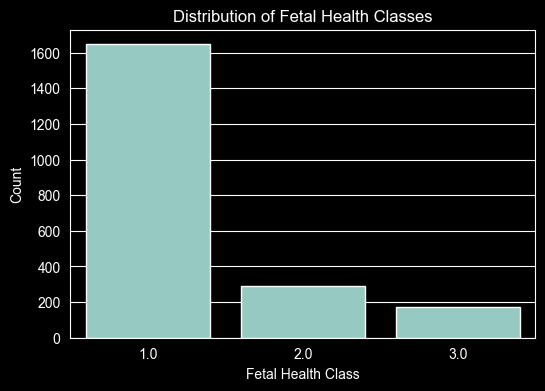

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='fetal_health', data=df)
plt.title('Distribution of Fetal Health Classes')
plt.xlabel('Fetal Health Class')
plt.ylabel('Count')
plt.show()

### Correlation Heatmap

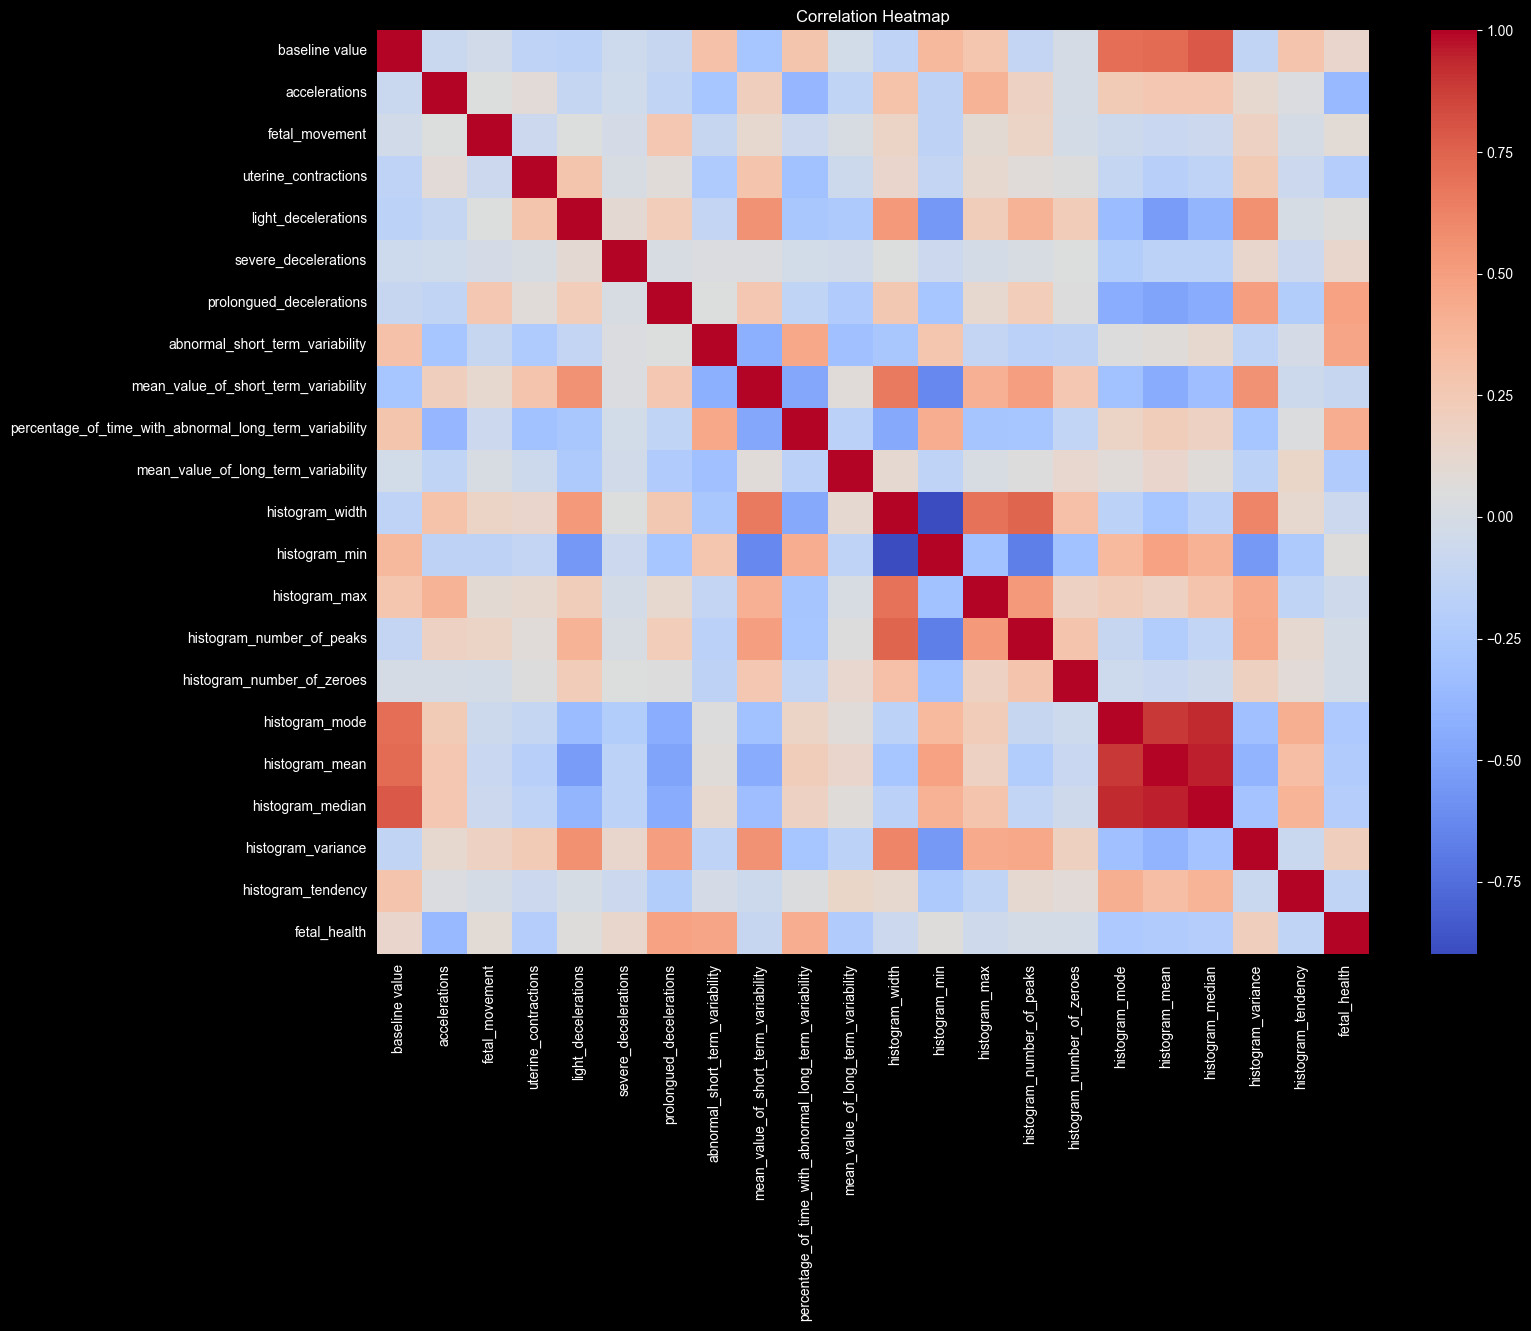

In [10]:
plt.figure(figsize=(16,12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Histogram of Numerical Features

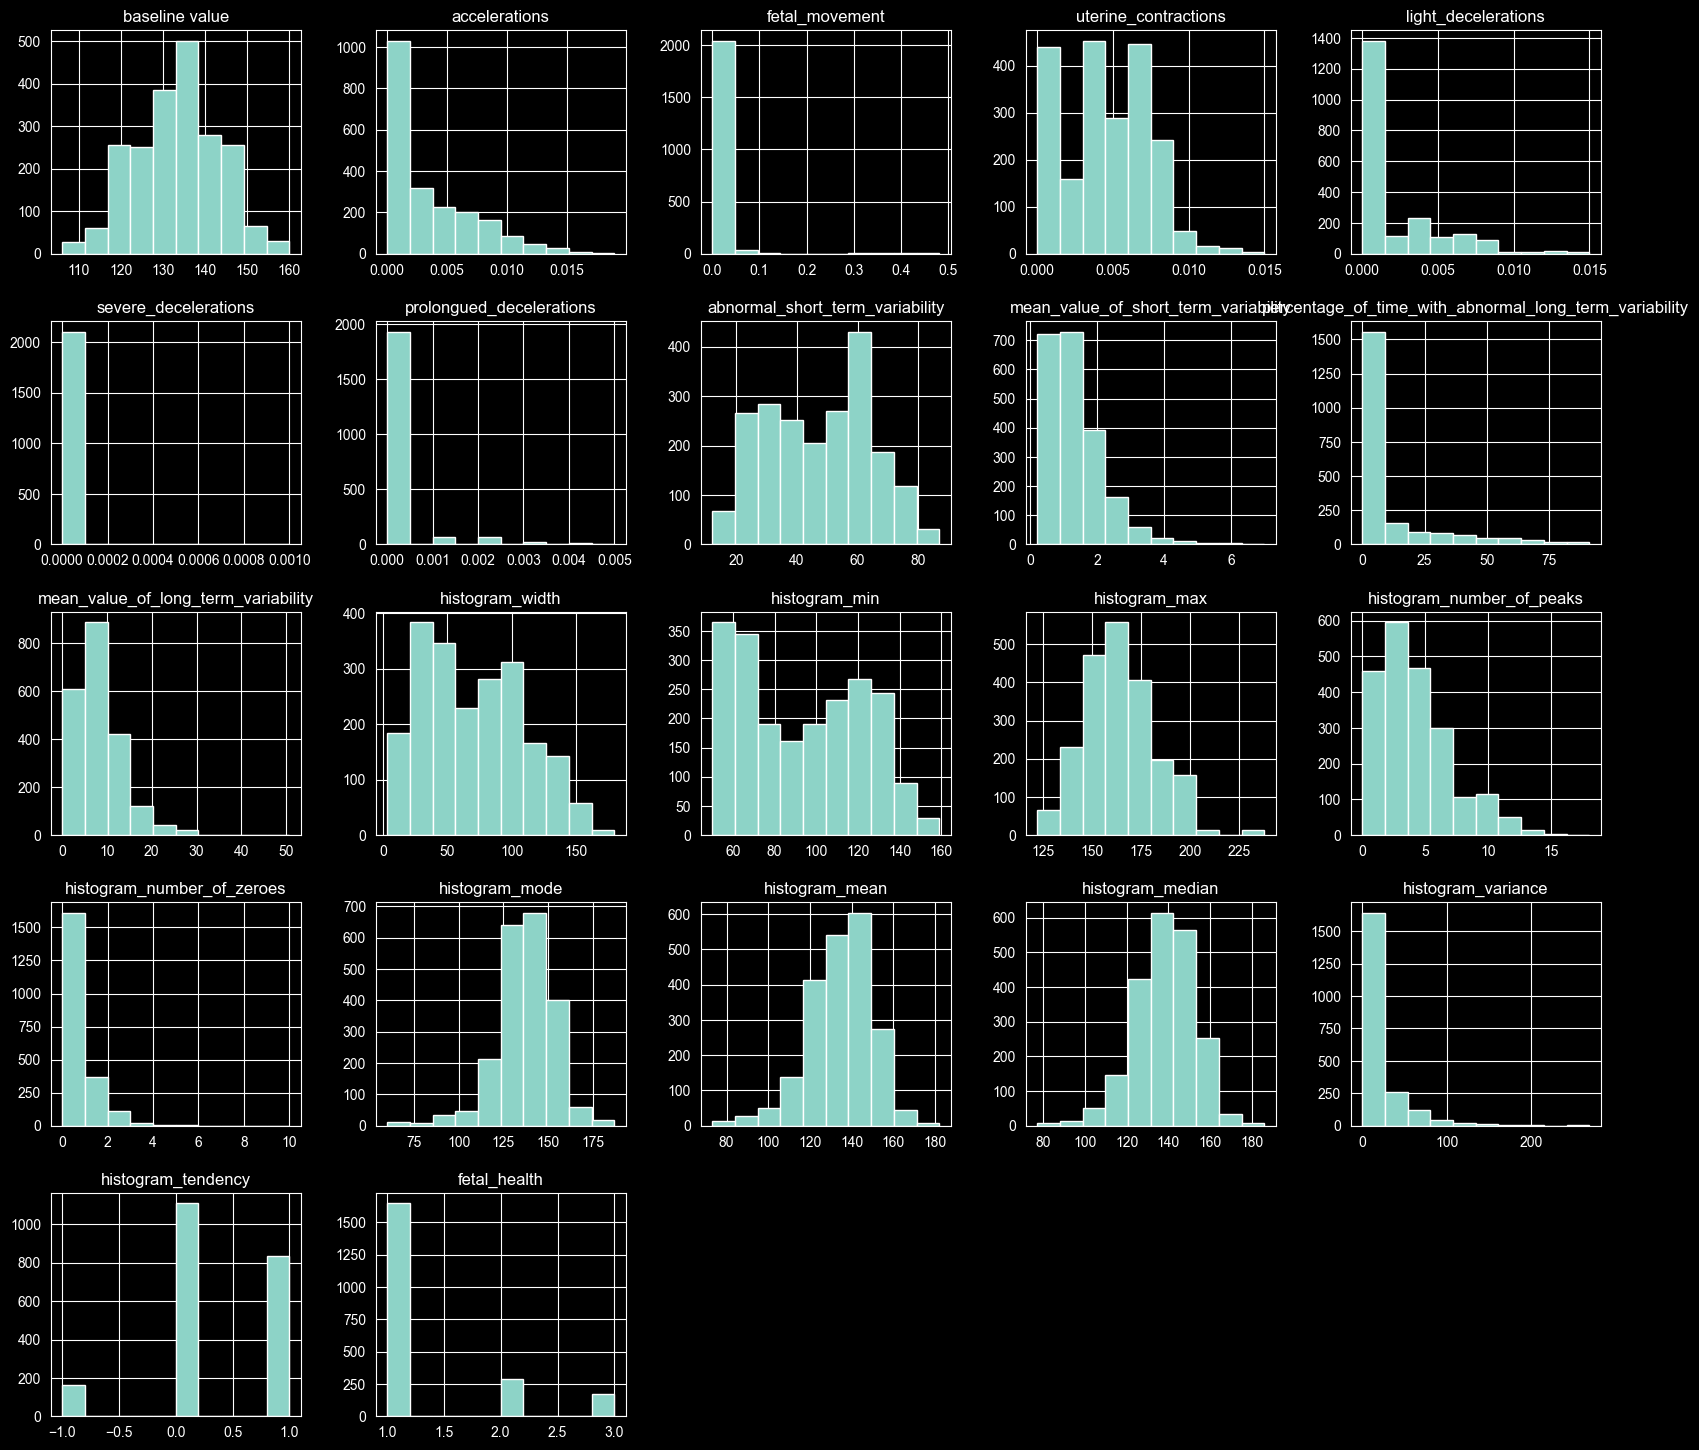

In [11]:
# Histograms
fig = df.hist(figsize=(20,18))
plt.show()

### Boxplot for Outlier Detection

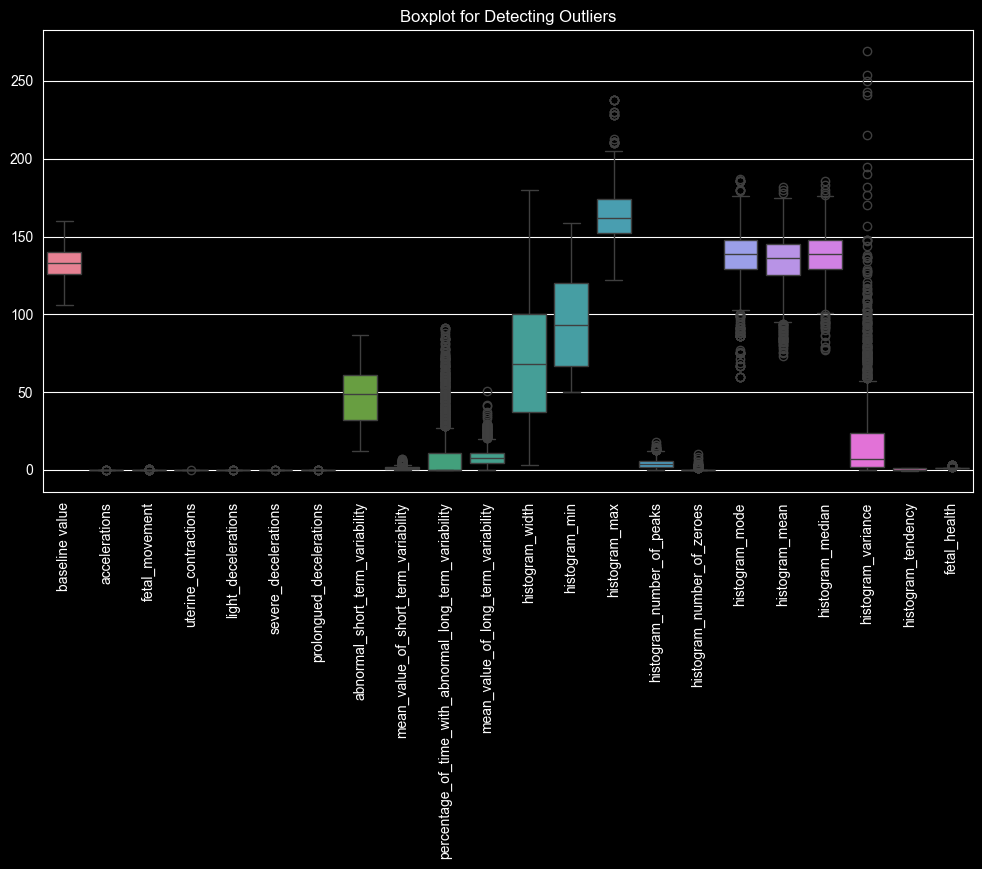

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title('Boxplot for Detecting Outliers')
plt.show()

### Pairplot Visualization

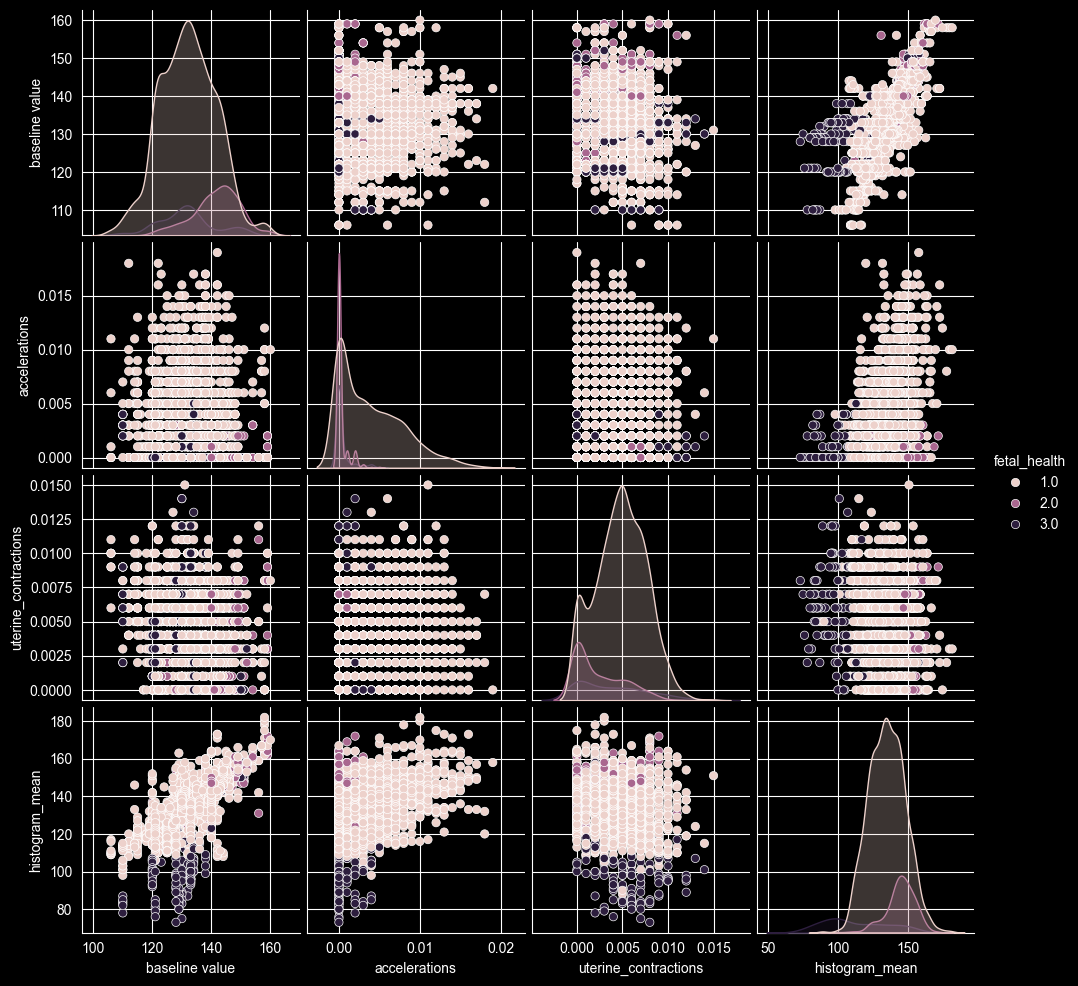

In [13]:
selected_features = [
    'baseline value',
    'accelerations',
    'uterine_contractions',
    'histogram_mean',
    'fetal_health'
]

sns.pairplot(df[selected_features], hue='fetal_health')
plt.show()

## 6. Feature Selection

In [14]:
# Features and target variable
X = df.drop('fetal_health', axis=1)
y = df['fetal_health']

## 7. Train-Test Split

In [15]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training Shape:', X_train.shape)
print('Testing Shape:', X_test.shape)

Training Shape: (1690, 21)
Testing Shape: (423, 21)


### 8. Feature Scaling

In [16]:
# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 9. Machine Learning Models

### Model 1: Logistic Regression

In [18]:
# Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Predictions
log_predictions = log_model.predict(X_test_scaled)

# Accuracy
log_accuracy = accuracy_score(y_test, log_predictions)
print('Logistic Regression Accuracy:', log_accuracy)

Logistic Regression Accuracy: 0.8888888888888888


### Classification Report

In [19]:
print(classification_report(y_test, log_predictions))

              precision    recall  f1-score   support

         1.0       0.92      0.96      0.94       330
         2.0       0.64      0.55      0.59        58
         3.0       0.90      0.77      0.83        35

    accuracy                           0.89       423
   macro avg       0.82      0.76      0.79       423
weighted avg       0.88      0.89      0.88       423



### Confusion Matrix

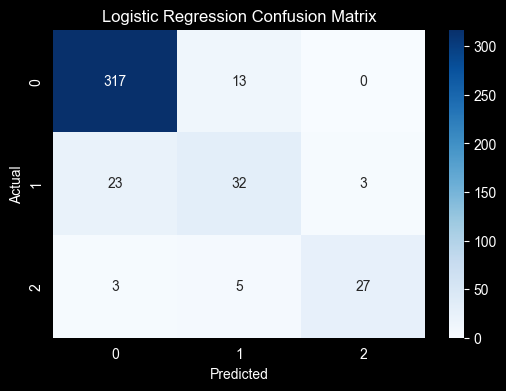

In [20]:
cm = confusion_matrix(y_test, log_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Model 2: Random Forest Classifier

In [21]:
# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)
print('Random Forest Accuracy:', rf_accuracy)

Random Forest Accuracy: 0.9527186761229315


### Classification Report

In [22]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

         1.0       0.95      0.99      0.97       330
         2.0       0.93      0.74      0.83        58
         3.0       0.97      0.91      0.94        35

    accuracy                           0.95       423
   macro avg       0.95      0.88      0.91       423
weighted avg       0.95      0.95      0.95       423



### Confusion Matrix

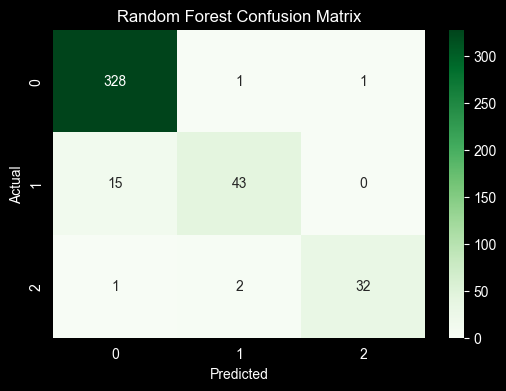

In [23]:
cm_rf = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 10. Model Comparison

In [24]:
# Model comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_accuracy, rf_accuracy]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.888889
1        Random Forest  0.952719


### Visualization of Model Performance

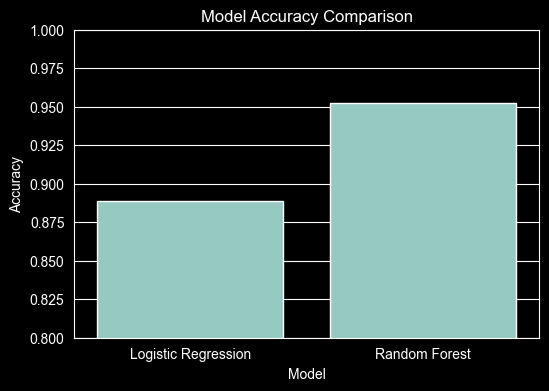

In [25]:
plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='Accuracy', data=comparison)
plt.title('Model Accuracy Comparison')
plt.ylim(0.8, 1.0)
plt.show()

## 11. Feature Importance (Random Forest)

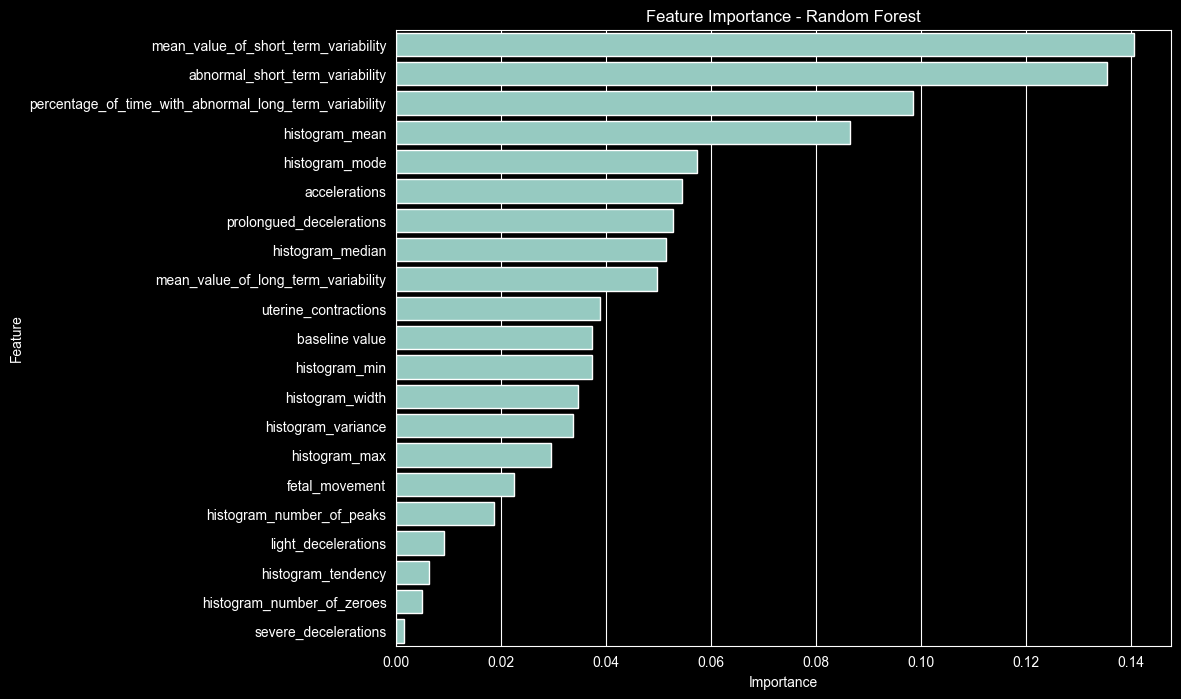

In [26]:
 # Feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance - Random Forest')
plt.show()